In [106]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split

In [107]:
df = pd.read_excel("premiums_young_with_gr.xlsx", sheet_name="Sheet1")
df = pd.concat([df, df['Medical History'].str.get_dummies(" & ")], axis = 1)
df.columns = df.columns.str.replace(" ", "_").str.lower()
# df = df.drop(['gender', 'region','medical_history'], axis = 1)
df = df.drop(['gender', 'income_lakhs', 'region', 'marital_status', 'income_level', 'medical_history', 'no_disease',
'employment_status', 'number_of_dependants'], axis = 1)
df = df.dropna()
df['smoking_status'] = df['smoking_status'].replace(['Does Not Smoke', 'Not Smoking', 'Smoking=0'], 'No Smoking')
y = df['annual_premium_amount'].copy()
x = df.drop(['annual_premium_amount'], axis = 1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=10, random_state=2)

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20094 entries, 0 to 20095
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    20094 non-null  int64 
 1   bmi_category           20094 non-null  object
 2   smoking_status         20094 non-null  object
 3   insurance_plan         20094 non-null  object
 4   annual_premium_amount  20094 non-null  int64 
 5   genetical_risk         20094 non-null  int64 
 6   diabetes               20094 non-null  int64 
 7   heart_disease          20094 non-null  int64 
 8   high_blood_pressure    20094 non-null  int64 
 9   thyroid                20094 non-null  int64 
dtypes: int64(7), object(3)
memory usage: 1.7+ MB


In [109]:
oe = OrdinalEncoder(
    categories=[   
        # ['Unmarried', 'Married'],       
        ['Underweight', 'Normal', 'Overweight', 'Obesity'],       
        ['No Smoking', 'Occasional', 'Regular'],
        # ['Freelancer', 'Self-Employed', 'Salaried'],       
        # ['<10L', '10L - 25L', '25L - 40L','> 40L'],       
        ['Bronze', 'Silver', 'Gold']       
    ]
)

In [110]:
#scaling not required
num_cols = [
    "age",
    'genetical_risk',
    'diabetes',	
    'heart_disease',
    'high_blood_pressure',
    'thyroid',
    # 'number_of_dependants',
    # 'income_lakhs',
]

# All remaining columns → ordinal
ordinal_col = [
    # "marital_status",
    "bmi_category",
    "smoking_status",
    # 'employment_status',
    # 'income_level',
    "insurance_plan"
]

# nominal_col = ["employment_status"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", oe, ordinal_col)
        # ("nominal", OneHotEncoder(handle_unknown="ignore", drop = "first"), nominal_col)
    ]
)

In [111]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("tree", RandomForestRegressor())
])

model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'genetical_risk',
                                                   'diabetes', 'heart_disease',
                                                   'high_blood_pressure',
                                                   'thyroid']),
                                                 ('cat',
                                                  OrdinalEncoder(categories=[['Underweight',
                                                                              'Normal',
                                                                              'Overweight',
                                                                              'Obesity'],
                                                                             ['No '
                                                                              'Smoking',
                                                                              'Occasional',
                                                                              'Regular'],
                                                                             ['Bronze',
                                                                              'Silver',
                                                                              'Gold']]),
                                                  ['bmi_category',
                                                   'smoking_status',
                                                   'insurance_plan'])])),
                ('tree', RandomForestRegressor())])

In [117]:
# r2 score
model.score(x_test, y_test)

0.984923537666596

In [98]:
model.feature_names_in_

array(['age', 'bmi_category', 'smoking_status', 'insurance_plan',
       'genetical_risk', 'diabetes', 'heart_disease',
       'high_blood_pressure', 'thyroid'], dtype=object)

In [118]:
import joblib

joblib.dump(model, 'healthcare_premium_ml/artifacts/young_gr_model_2.pkl')

['healthcare_premium_ml/artifacts/young_gr_model_2.pkl']

wow, for age < 25 dataset the r2 score is good

In [86]:
# Get feature names after preprocessing
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importances = model.named_steps["tree"].feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances*100
})

# Sort
importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(importance_df)

                    feature  importance
8       cat__insurance_plan   58.647797
1       num__genetical_risk   38.666371
7       cat__smoking_status    0.861411
6         cat__bmi_category    0.690990
3        num__heart_disease    0.502013
2             num__diabetes    0.248720
0                  num__age    0.171965
4  num__high_blood_pressure    0.133551
5              num__thyroid    0.077182


<Axes: xlabel='diff_pct', ylabel='Count'>

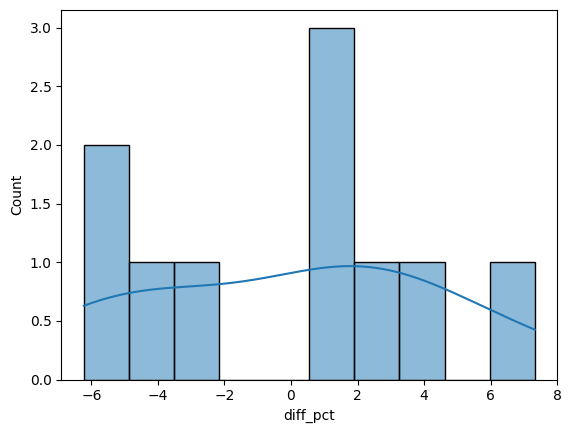

In [100]:
# error analysis
y_pred = model.predict(x_test)
residuals = y_pred - y_test
res_pct = residuals*100 / y_test

results = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'diff': residuals,
    'diff_pct': res_pct
    })

sns.histplot(results['diff_pct'], bins = 10, kde=True)

In [90]:
th = 10
extreme_df = results[np.abs(results['diff_pct']) > th]
extreme_df

,actual,predicted,diff,diff_pct


In [91]:
err_pct = len(extreme_df)*100 / len(results)
err_pct

0.0

all errors below 10% error band